<a href="https://colab.research.google.com/github/erickgnfi-dotcom/Analisis-de-tendencias-financieras-en-bolsa-/blob/main/Analisis_de_tendencias_financieras_en_bolsa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Descargando datos históricos...


/tmp/ipykernel_908/690966212.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2021-01-01", end="2026-01-01")['Close']
[*********************100%***********************]  2 of 2 completed


Ticker,HERDEZ.MX,NFLX
Date,,
2021-01-04,42.769985,52.285999
2021-01-05,39.911396,52.080002
2021-01-06,38.438576,50.049000
2021-01-07,37.125370,50.889000
2021-01-08,37.350277,51.040001


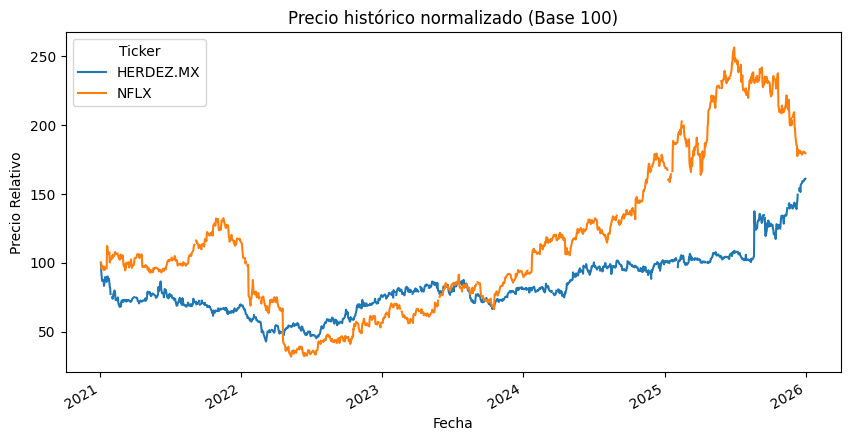

In [1]:
# Instalar yfinance por si no está disponible
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Definir los tickers (Netflix y Herdez en la bolsa mexicana)
tickers = ['NFLX', 'HERDEZ.MX']

print("Descargando datos históricos...")
# Descargar datos de los últimos 5 años
data = yf.download(tickers, start="2021-01-01", end="2026-01-01")['Close']

# Mostrar las primeras filas
display(data.head())

# Graficar el comportamiento histórico normalizado para comparar
(data / data.iloc[0] * 100).plot(figsize=(10, 5))
plt.title("Precio histórico normalizado (Base 100)")
plt.xlabel("Fecha")
plt.ylabel("Precio Relativo")
plt.show()

In [2]:
display(data.tail())

Ticker,HERDEZ.MX,NFLX
Date,,
2025-12-24,68.051170,93.639999
2025-12-26,67.969292,94.470001
2025-12-29,68.739059,94.150002
2025-12-30,68.624413,93.779999
2025-12-31,68.788193,93.760002


In [34]:
import numpy as np

# Trabajaremos primero con Netflix ('NFLX') para estructurar el pipeline
df = pd.DataFrame()
df['Close'] = data['NFLX']

# 1. Crear la Variable Objetivo (Target): 1 si el precio de mañana es mayor que hoy, 0 si baja
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# 2. Ingeniería de características (Features)
# Rezagos (Lags): Precio de los últimos 3 días
df['Lag_1'] = df['Close'].shift(1)
df['Lag_2'] = df['Close'].shift(2)
df['Lag_3'] = df['Close'].shift(3)

# Retornos diarios (Cambio porcentual)
df['Return_1d'] = df['Close'].pct_change(1)

# Indicador técnico simple: Media Móvil Simple (SMA) de 10 y 50 días
df['SMA_10'] = df['Close'].rolling(window=10).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# Relación entre precio y medias móviles
df['Price_vs_SMA10'] = df['Close'] / df['SMA_10']

# Limpiar valores nulos generados por los rezagos y las medias móviles
df = df.dropna()

print("¡Características creadas con éxito! Dimensiones del DataFrame:", df.shape)
display(df.tail())

¡Características creadas con éxito! Dimensiones del DataFrame: (150, 9)


/tmp/ipykernel_908/1399644455.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Return_1d'] = df['Close'].pct_change(1)


,Close,Target,Lag_1,Lag_2,Lag_3,Return_1d,SMA_10,SMA_50,Price_vs_SMA10
Date,,,,,,,,,
2025-11-20,105.669998,0,110.000000,114.089996,110.290001,-0.039364,111.845699,116.27712,0.944784
2025-11-21,104.309998,1,105.669998,110.000000,114.089996,-0.012870,111.240099,115.98644,0.937701
2025-11-24,106.970001,0,104.309998,105.669998,110.000000,0.025501,110.736399,115.72132,0.965988
2025-11-25,104.400002,1,106.970001,104.309998,105.669998,-0.024025,109.812000,115.40830,0.950716
2025-11-26,106.139999,0,104.400002,106.970001,104.309998,0.016667,108.850999,115.07410,0.975094


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Separar características (X) y variable objetivo (y)
# Quitamos 'Close' y 'Target' de las variables predictoras
features = ['Lag_1', 'Lag_2', 'Lag_3', 'Return_1d', 'SMA_10', 'SMA_50', 'Price_vs_SMA10']
X = df[features]
y = df['Target']

# 2. División cronológica (Time Series Split manual)
# Usaremos 80% de los datos para entrenar y 20% para probar el futuro
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Datos de entrenamiento: {len(X_train)} filas")
print(f"Datos de prueba (futuro): {len(X_test)} filas")

# 3. Inicializar y entrenar un modelo clásico de Machine Learning (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
model.fit(X_train, y_train)

# 4. Evaluar el modelo en el conjunto de prueba
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n--- Resultados del Modelo para Netflix ---")
print(f"Precisión (Accuracy) en datos de prueba: {acc:.4f}")
print("\nReporte detallado de clasificación:")
print(classification_report(y_test, y_pred))

Datos de entrenamiento: 120 filas
Datos de prueba (futuro): 30 filas

--- Resultados del Modelo para Netflix ---
Precisión (Accuracy) en datos de prueba: 0.5000

Reporte detallado de clasificación:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.50      1.00      0.67        15

    accuracy                           0.50        30
   macro avg       0.25      0.50      0.33        30
weighted avg       0.25      0.50      0.33        30



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Importancia de Características ---


,Feature,Importance
6,Price_vs_SMA10,0.196080
3,Return_1d,0.167157
5,SMA_50,0.144125
1,Lag_2,0.130401
2,Lag_3,0.124911
0,Lag_1,0.121347
4,SMA_10,0.115979


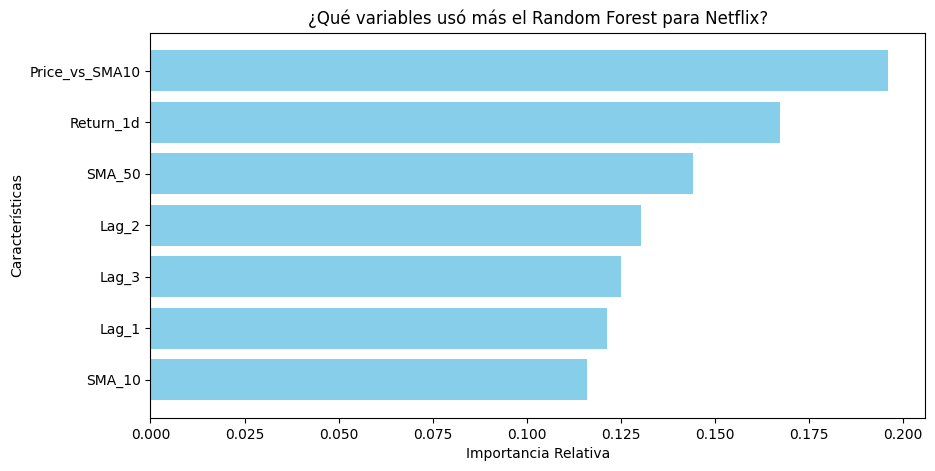

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extraer la importancia de cada variable del modelo entrenado
importances = model.feature_importances_
feature_names = X.columns

# 2. Crear un DataFrame para ordenar los resultados de mayor a menor
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("--- Importancia de Características ---")
display(feature_importance_df)

# 3. Graficar los resultados
plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importancia Relativa')
plt.ylabel('Características')
plt.title('¿Qué variables usó más el Random Forest para Netflix?')
plt.gca().invert_yaxis() # Para que la más importante quede arriba
plt.show()

In [37]:
# 1. Agregamos una nueva característica: Volatilidad (desviación estándar de los retornos a 10 días)
df['Volatility_10'] = df['Return_1d'].rolling(window=10).std()

# Limpiamos nuevamente los nulos que genera la volatilidad
df = df.dropna()

# 2. Actualizamos nuestra lista de características
features = ['Lag_1', 'Lag_2', 'Lag_3', 'Return_1d', 'SMA_10', 'SMA_50', 'Price_vs_SMA10', 'Volatility_10']
X = df[features]
y = df['Target']

# 3. Mantenemos la división cronológica estricta
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 4. Ajustamos hiperparámetros del Random Forest (un poco más de profundidad y árboles)
model_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=3,        # Profundidad baja para evitar sobreajuste severo en ruido financiero
    min_samples_split=20, # Exigir más muestras por nodo
    random_state=42
)
model_v2.fit(X_train, y_train)

# 5. Evaluación
y_pred_v2 = model_v2.predict(X_test)
acc_v2 = accuracy_score(y_test, y_pred_v2)

print(f"--- Resultados del Modelo V2 (con Volatilidad y Ajustes) ---")
print(f"Nueva Precisión (Accuracy): {acc_v2:.4f}")
print("\nReporte detallado de clasificación:")
print(classification_report(y_test, y_pred_v2))

--- Resultados del Modelo V2 (con Volatilidad y Ajustes) ---
Nueva Precisión (Accuracy): 0.4828

Reporte detallado de clasificación:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.48      1.00      0.65        14

    accuracy                           0.48        29
   macro avg       0.24      0.50      0.33        29
weighted avg       0.23      0.48      0.31        29



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
# 1. Regresamos a las características originales (sin volatilidad)
features = ['Lag_1', 'Lag_2', 'Lag_3', 'Return_1d', 'SMA_10', 'SMA_50', 'Price_vs_SMA10']
X = df[features]
y = df['Target']

# Mantenemos la división cronológica estricta
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 2. Definimos una lista de profundidades (max_depth) a probar
profundidades = [2, 3, 5, 8, 10, 15, 20, None]
resultados = []

print("--- Evaluando distintas profundidades (max_depth) ---")
for profundidad in profundidades:
    # Entrenar modelo con la profundidad actual
    model_loop = RandomForestClassifier(n_estimators=100, max_depth=profundidad, random_state=42)
    model_loop.fit(X_train, y_train)

    # Evaluar en train y en test para detectar overfitting
    y_pred_train = model_loop.predict(X_train)
    y_pred_test = model_loop.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    resultados.append({
        'Max_Depth': str(profundidad),
        'Accuracy_Train': acc_train,
        'Accuracy_Test': acc_test
    })

# 3. Mostrar los resultados en una tabla limpia
df_resultados = pd.DataFrame(resultados)
display(df_resultados)

--- Evaluando distintas profundidades (max_depth) ---


,Max_Depth,Accuracy_Train,Accuracy_Test
0,2,0.660714,0.482759
1,3,0.812500,0.482759
2,5,0.928571,0.482759
3,8,1.000000,0.482759
4,10,1.000000,0.482759
5,15,1.000000,0.482759
6,20,1.000000,0.482759
7,None,1.000000,0.482759


In [39]:
# 1. Descargar datos limpios para Herdez
ticker_herdez = 'HERDEZ.MX'
df_h = pd.DataFrame()
df_h['Close'] = yf.download(ticker_herdez, start="2021-01-01", end="2026-01-01", progress=False)['Close']

# Si multiindex (dependiendo de la versión de yfinance), aplanamos la columna
if isinstance(df_h['Close'], pd.DataFrame):
    df_h['Close'] = df_h['Close'].iloc[:, 0]

# 2. Replicar la ingeniería de características
df_h['Target'] = (df_h['Close'].shift(-1) > df_h['Close']).astype(int)
df_h['Lag_1'] = df_h['Close'].shift(1)
df_h['Lag_2'] = df_h['Close'].shift(2)
df_h['Lag_3'] = df_h['Close'].shift(3)
df_h['Return_1d'] = df_h['Close'].pct_change(1)
df_h['SMA_10'] = df_h['Close'].rolling(window=10).mean()
df_h['SMA_50'] = df_h['Close'].rolling(window=50).mean()
df_h['Price_vs_SMA10'] = df_h['Close'] / df_h['SMA_10']

df_h = df_h.dropna()

# 3. Separar X e y
features = ['Lag_1', 'Lag_2', 'Lag_3', 'Return_1d', 'SMA_10', 'SMA_50', 'Price_vs_SMA10']
X_h = df_h[features]
y_h = df_h['Target']

# 4. División cronológica
split_index_h = int(len(df_h) * 0.8)
X_train_h, X_test_h = X_h.iloc[:split_index_h], X_h.iloc[split_index_h:]
y_train_h, y_test_h = y_h.iloc[:split_index_h], y_h.iloc[split_index_h:]

# 5. Ciclo for para probar profundidades en Herdez
resultados_h = []

print(f"--- Evaluando distintas profundidades para Herdez ({ticker_herdez}) ---")
for profundidad in profundidades:
    model_loop_h = RandomForestClassifier(n_estimators=100, max_depth=profundidad, random_state=42)
    model_loop_h.fit(X_train_h, y_train_h)

    y_pred_train_h = model_loop_h.predict(X_train_h)
    y_pred_test_h = model_loop_h.predict(X_test_h)

    acc_train_h = accuracy_score(y_train_h, y_pred_train_h)
    acc_test_h = accuracy_score(y_test_h, y_pred_test_h)

    resultados_h.append({
        'Max_Depth': str(profundidad),
        'Accuracy_Train': acc_train_h,
        'Accuracy_Test': acc_test_h
    })

df_resultados_h = pd.DataFrame(resultados_h)
display(df_resultados_h)

/tmp/ipykernel_908/523727748.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_h['Close'] = yf.download(ticker_herdez, start="2021-01-01", end="2026-01-01", progress=False)['Close']


--- Evaluando distintas profundidades para Herdez (HERDEZ.MX) ---


,Max_Depth,Accuracy_Train,Accuracy_Test
0,2,0.597725,0.537190
1,3,0.623578,0.537190
2,5,0.731127,0.553719
3,8,0.900724,0.574380
4,10,0.970010,0.570248
5,15,1.000000,0.574380
6,20,1.000000,0.582645
7,None,1.000000,0.574380


In [40]:
# 1. Asegurarnos de tener instalado xgboost (Colab ya suele traerlo, pero por si acaso)
!pip install xgboost --quiet

import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

print("--- Entrenando modelo XGBoost para Grupo Herdez ---")

# 2. Inicializar el clasificador de XGBoost
# Usaremos 'logloss' como función de pérdida para clasificación binaria
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,           # Profundidad conservadora para evitar overfitting
    learning_rate=0.05,    # Tasa de aprendizaje para que el boosting sea gradual
    random_state=42,
    eval_metric='logloss'
)

# 3. Entrenar el modelo con los datos de entrenamiento de Herdez que ya teníamos en memoria
xgb_model.fit(X_train_h, y_train_h)

# 4. Evaluar en train y en test
y_pred_train_xgb = xgb_model.predict(X_train_h)
y_pred_test_xgb = xgb_model.predict(X_test_h)

acc_train_xgb = accuracy_score(y_train_h, y_pred_train_xgb)
acc_test_xgb = accuracy_score(y_test_h, y_pred_test_xgb)

print(f"\nResultados XGBoost (Herdez):")
print(f"Accuracy en Train: {acc_train_xgb:.4f}")
print(f"Accuracy en Test (Futuro): {acc_test_xgb:.4f}")
print("\nReporte detallado de clasificación en Test:")
print(classification_report(y_test_h, y_pred_test_xgb))

--- Entrenando modelo XGBoost para Grupo Herdez ---

Resultados XGBoost (Herdez):
Accuracy en Train: 0.7218
Accuracy en Test (Futuro): 0.5826

Reporte detallado de clasificación en Test:
              precision    recall  f1-score   support

           0       0.57      0.91      0.70       128
           1       0.68      0.22      0.33       114

    accuracy                           0.58       242
   macro avg       0.62      0.56      0.51       242
weighted avg       0.62      0.58      0.52       242

